## Setup

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np

## Prepare data

In [169]:
#Load data
df = pd.read_csv("scottish_munros.csv")

#filter for only currently active munros
print(len(df))
df = df[df["2021"]=="Munro"].reset_index(drop=True)
print(len(df))

#print dataframe
df.head()

604
282


,DoBIH_number,Name,Height_m,Height_ft,xcoord,ycoord,1891,1921,1933,1953,1969,1974,1981,1984,1990,1997,2021,Comments
0,1,Ben Chonzie,931.0,3054.0,277324.0,730857.0,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,NaN
1,17,Ben Vorlich,985.3,3233.0,262912.0,718916.0,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,NaN
2,18,Stuc a' Chroin,973.0,3192.0,261746.0,717465.0,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,NaN
3,32,Ben Lomond,973.7,3195.0,236707.0,702863.0,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,NaN
4,26,Ben More,1174.0,3852.0,243276.0,724417.0,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,NaN


In [170]:
def cartesian_bearing(x1, y1, x2, y2):
    dx = x2 - x1
    dy = y2 - y1
    angle_rad = math.atan2(dx, dy)
    bearing_deg = (math.degrees(angle_rad) + 360) % 360
    return bearing_deg

#calculate bearing from each munro to Ben Nevis/id=278 (highest mountain)
nevis_y = df[df["DoBIH_number"]=="278"]["ycoord"]
nevis_x = df[df["DoBIH_number"]=="278"]["xcoord"]

bearings = []
for i in range(len(df)):
    bearing = cartesian_bearing(nevis_x, nevis_y, df.iloc[i]["xcoord"], df.iloc[i]["ycoord"])
    bearings.append(bearing)

df["bearing"] = bearings

In [171]:
#round height to nearest 10m
df["Height_m_round"] = [round(i, -1) for i in df["Height_m"]]
df["radius"] = [abs(1340 - i) for i in df["Height_m_round"] ]

#round height to nearest 20m
df["Height_m_round_20"] = [round(i /20) *20 for i in df["Height_m"]]
df["radius_20"] = [abs(1340 - i) for i in df["Height_m_round_20"] ]

In [ ]:
#calculate how many times defined as munro or munro top
df["munro_times"] = df[['1891', '1921', '1933', '1953', '1969', '1974', '1981', '1984', '1990',
       '1997', '2021']].apply(lambda row: ((row == "Munro")  | (row == "Munro Top")).sum(), axis=1).astype(float)

## Visualise

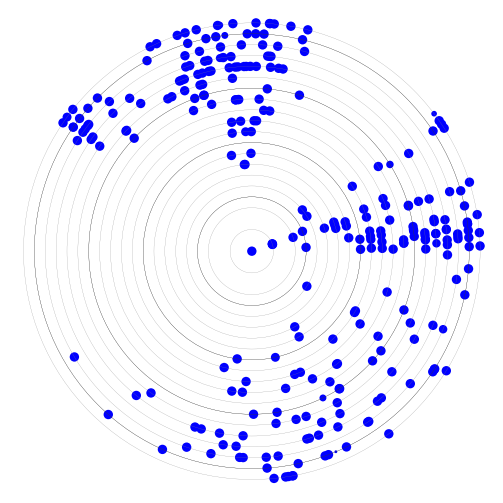

In [174]:
#reduce column list
df_plot = df[['DoBIH_number', 'Name', 'Height_m', 'Height_m_round_20', 'radius_20', 'bearing', 'munro_times']].copy()

#calculate coordinates to plot
df_plot["angle_rad"] = [math.radians(90 - i) for i in df_plot["bearing"]]
df_plot["xplot"] = df_plot["radius_20"] * np.cos(df_plot["angle_rad"])
df_plot["yplot"] = df_plot["radius_20"] * np.sin(df_plot["angle_rad"])


#plot ------------------------------------------------
fig, ax = plt.subplots(figsize =(9,9))

#plot munros
ax.scatter(df_plot["xplot"], df_plot["yplot"],
           s=df_plot["munro_times"]*8,  
           c='blue',                  
           edgecolors='none')       

ax.set_aspect('equal')



maxradius = 450
ax.set_xlim(- maxradius, maxradius)
ax.set_ylim(-maxradius, maxradius)

#draw radius (=height elevation line)
for radius in df_plot["radius_20"].unique():
    circle = plt.Circle((0, 0), radius, fill=False, edgecolor="grey", linestyle='solid', linewidth=0.2)
    ax.add_patch(circle)

for radius in [100,200,300,400]:
    circle = plt.Circle((0, 0), radius, fill=False, edgecolor="black",linestyle='solid', linewidth=0.2)
    ax.add_patch(circle)

#remove axis
ax.axis("off")

plt.show()

## Playground

In [166]:
df.sort_values(by="Height_m", ascending=False)

,DoBIH_number,Name,Height_m,Height_ft,xcoord,ycoord,1891,1921,1933,1953,...,1990,1997,2021,Comments,bearing,Height_m_round,radius,Height_m_round_20,radius_20,munro_times
72,278,Ben Nevis,1344.53,4411.0,216666.0,771288.0,Munro,Munro,Munro,Munro,...,Munro,Munro,Munro,NaN,0.000000,1340.0,0.0,1340,0,11.0
151,518,Ben Macdui [Beinn Macduibh],1309.00,4295.0,298899.0,798943.0,Munro,Munro,Munro,Munro,...,Munro,Munro,Munro,1891-1953: Ben Macdhui,71.412181,1310.0,30.0,1300,40,11.0
144,519,Braeriach,1296.00,4252.0,295328.0,799916.0,Munro,Munro,Munro,Munro,...,Munro,Munro,Munro,NaN,70.001689,1300.0,40.0,1300,40,11.0
146,521,Cairn Toul,1291.00,4236.0,296328.0,797229.0,Munro,Munro,Munro,Munro,...,Munro,Munro,Munro,NaN,71.962765,1290.0,50.0,1300,40,11.0
145,523,Sgor an Lochain Uaine,1258.00,4127.0,295422.0,797693.0,Munro,Munro,Munro,Munro,...,Munro,Munro,Munro,"1891: Sgor an Lochain Uaine, Carn Toul; 1921-1...",71.464931,1260.0,80.0,1260,80,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,759,Meall na Teanga,916.80,3008.0,222023.0,792471.0,Munro,Munro,Munro,Munro,...,Munro,Munro,Munro,1891: Meall an Teanga,14.192061,920.0,420.0,920,420,11.0
14,75,Beinn a' Chleibh,916.30,3006.0,225054.0,725606.0,Munro,Munro,Munro,Munro,...,Munro,Munro,Munro,NaN,169.595409,920.0,420.0,920,420,11.0
17,76,Ben Vane,915.76,3004.0,227753.0,709844.0,Munro,Munro,Munro,Munro,...,Munro,Munro,Munro,NaN,169.771569,920.0,420.0,920,420,11.0
127,438,Carn Aosda,915.30,3003.0,313397.0,779164.0,Munro,Munro,Munro,Munro,...,Munro,Munro,Munro,NaN,85.345150,920.0,420.0,920,420,11.0


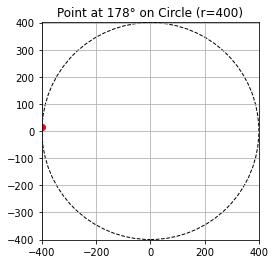

In [55]:
radius = 400
bearing = 178

# Convert to radians
angle_rad = np.radians(bearing)

# Calculate coordinates
x = radius * np.cos(angle_rad)
y = radius * np.sin(angle_rad)

# Plot
fig, ax = plt.subplots()
ax.plot(x, y, 'ro')  # red dot
ax.set_aspect('equal')
ax.set_xlim(-radius - 1, radius + 1)
ax.set_ylim(-radius - 1, radius + 1)

# Optional: draw the circle for context
circle = plt.Circle((0, 0), radius, fill=False, linestyle='--')
ax.add_patch(circle)

plt.title(f"Point at {bearing}° on Circle (r={radius})")
plt.grid(True)
plt.show()
